In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [5]:
# Function to Build the Quantum Circuit

# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N-1):
        qc.cx(i, i+1)
        qc.rz(x[i] * x[i+1], i+1)
        qc.cx(i, i+1)
    qc.barrier()
    return qc

# -----------------------
# Variational Model
# -----------------------
def Ansatz(N):
    theta = ParameterVector('theta', 2*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(N-1):
        qc.cx(i, i+1)
    qc.barrier()
    for i in range(N):
        qc.ry(theta[i+N], i)
    return qc


In [6]:
# Read and scale data from Iris Dataset
df=pd.read_csv("Iris/iris.data",header=None, 
               names = ["S-length", "S-width", "P-length","P-width","label"])


# Filter for binary classification
df = df[df["label"].isin(["Iris-setosa", "Iris-versicolor"])]

feature_col = ["S-length", "S-width", "P-length","P-width"]
label_col   = "label"

x = df[feature_col].values
y = LabelEncoder().fit_transform(df["label"].values)

# Conversion features in [-1,1]
scaler   = MinMaxScaler(feature_range=(-1, 1))        
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y
)

N = len(feature_col)
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz(N)

## QNN

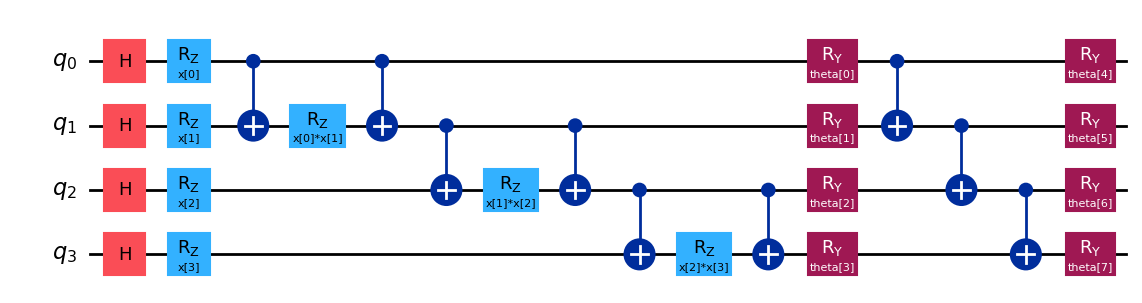

In [7]:
qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

## easy Quantum Model

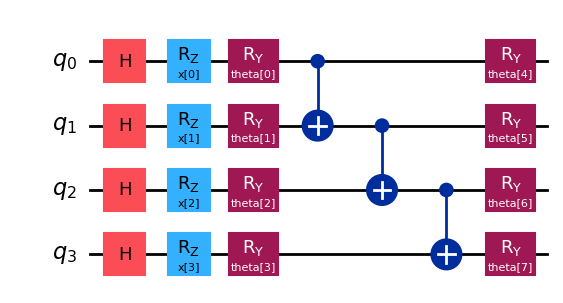

In [8]:
easy_qc = easy_feature_map.copy().compose(ansatz.copy())
easy_qc.draw("mpl", style="iqp", plot_barriers=False)

## Evaluating Loss for QNNs

In [11]:
# Function to get the loss value
def make_adam_tracker(loss_list, maxiter=100,N=4):
    log_n = np.log2(N)
    def adam_with_tracking(fun, x0, jac=None, **kwargs):
        optimizer = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(weights):
            loss = fun(weights)
            loss_norm = float(loss) / log_n
            loss_list.append(float(loss_norm))
            pct = len(loss_list)/maxiter * 100
            bar = "#"*int( pct//5 ) + "."*( 20 - int(pct//5) )  
            print(f"\r[{bar}] iter {len(loss_list):>3d} | loss: {loss:.4f}",flush=True)
            return jac(weights)
        return optimizer.minimize(fun=fun, x0=x0, jac=tracked_jac)
    return adam_with_tracking

# ── Optimizing the circuits ───────────────────────────────────────────────────────
qc_loss      = []
qc_easy_loss = []

vqc = VQC(
    sampler=StatevectorSampler(),
    feature_map=FeatureMap(N),
    ansatz=Ansatz(N),
    optimizer=make_adam_tracker(qc_loss),       
)
vqc.fit(x_train, y_train)

vqc_easy = VQC(
    sampler=StatevectorSampler(),
    feature_map=EasyFeatureMap(N),
    ansatz=Ansatz(N),
    optimizer=make_adam_tracker(qc_easy_loss),
)
vqc_easy.fit(x_train, y_train)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[....................] iter   1 | loss: 1.0988
[....................] iter   2 | loss: 1.0242
[....................] iter   3 | loss: 0.9968
[....................] iter   4 | loss: 1.0027
[#...................] iter   5 | loss: 1.0156
[#...................] iter   6 | loss: 1.0269
[#...................] iter   7 | loss: 1.0293
[#...................] iter   8 | loss: 1.0173
[#...................] iter   9 | loss: 1.0045
[##..................] iter  10 | loss: 0.9960
[##..................] iter  11 | loss: 1.0002
[##..................] iter  12 | loss: 1.0019
[##..................] iter  13 | loss: 1.0019
[##..................] iter  14 | loss: 1.0100
[###.................] iter  15 | loss: 1.0130
[###.................] iter  16 | loss: 1.0040
[###.................] iter  17 | loss: 0.9932
[###.................] iter  18 | loss: 0.9891
[###.................] iter  19 | loss: 1.0022
[####................] iter  20 | loss: 0.9897
[####................] iter  21 | loss: 0.9923
[####........

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[....................] iter   1 | loss: 1.0623
[....................] iter   2 | loss: 1.0105
[....................] iter   3 | loss: 1.0047
[....................] iter   4 | loss: 1.0149
[#...................] iter   5 | loss: 1.0146
[#...................] iter   6 | loss: 1.0244
[#...................] iter   7 | loss: 1.0116
[#...................] iter   8 | loss: 1.0100
[#...................] iter   9 | loss: 1.0018
[##..................] iter  10 | loss: 1.0014
[##..................] iter  11 | loss: 0.9971
[##..................] iter  12 | loss: 0.9943
[##..................] iter  13 | loss: 0.9960
[##..................] iter  14 | loss: 0.9993
[###.................] iter  15 | loss: 1.0100
[###.................] iter  16 | loss: 1.0009
[###.................] iter  17 | loss: 0.9976
[###.................] iter  18 | loss: 1.0061
[###.................] iter  19 | loss: 1.0012
[####................] iter  20 | loss: 1.0083
[####................] iter  21 | loss: 0.9979
[####........

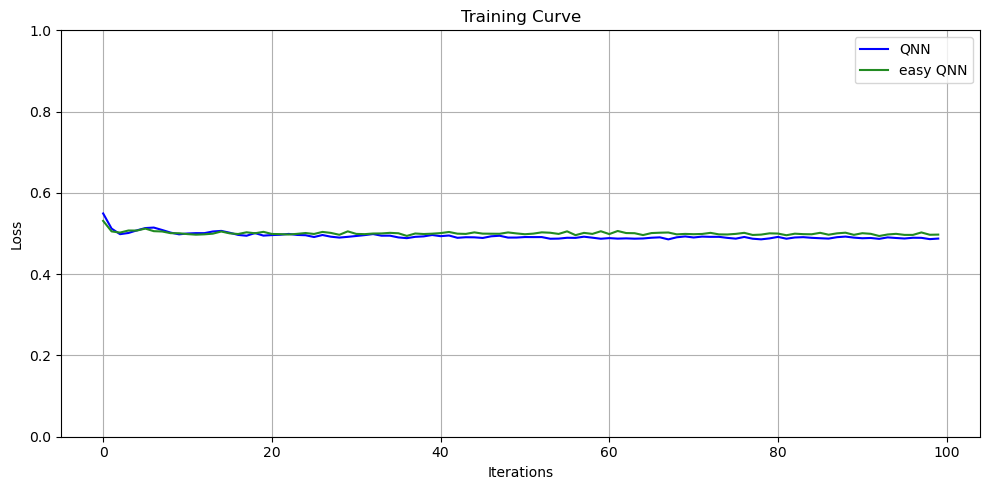

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(qc_loss, label = "QNN", color = 'blue')
plt.plot(qc_easy_loss, label = "easy QNN", color = 'forestgreen')
plt.ylim([0,1])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()